In [6]:
import pandas as pd
import numpy as np
import astropy.coordinates as coord
import astropy.units as u
from sklearn.mixture import GaussianMixture

print("EFT-Lapse **OHNE COLUMNS** - Position-only!")

local_path = r'C:\Users\HP\Documents\Ideen\Timescape\5.1\Addendum K Tests\K1\lcparam_full_long.txt'
df = pd.read_csv(local_path, sep=r'\s+', comment='#', header=None, na_values=['', 'nan'])
print(f"Shape: {df.shape}")

# POSITIONEN (STANDARD Pantheon): 2=zhel, 4=mb, 5=dmb, 16=ra, 17=dec, -1=biascor
zHD = df.iloc[:, 2]  # zhel
mb_raw = df.iloc[:, 4]  # mb
dmb = df.iloc[:, 5].abs()  # Fehler
biascor = df.iloc[:, -1].fillna(0)  # Letzte Spalte
m_b_corr = mb_raw + biascor
m_b_corr_err = dmb

ra = df.iloc[:, 16]  # ra
dec = df.iloc[:, 17]  # dec

print("Daten OK! Erste 3:")
print(pd.DataFrame({'zHD':zHD[:3], 'mb':mb_raw[:3], 'dmb':dmb[:3], 'biascor':biascor[:3]}))

# Koordinaten
mask_c = ra.notna() & dec.notna()
sky = coord.SkyCoord(ra=ra[mask_c]*u.deg, dec=dec[mask_c]*u.deg)
b_gal = sky.galactic.b.deg
ga_pos = coord.SkyCoord(150*u.deg, -45*u.deg)
ga_sep = sky.separation(ga_pos).deg

# PURE
print("\n=== PURE zHD 0.02-0.045 err<0.15 ===")
mask_pure = (zHD > 0.02) & (zHD < 0.045) & (m_b_corr_err < 0.15) & m_b_corr.notna()
mb_pure = m_b_corr[mask_pure].dropna().values.reshape(-1, 1)
print(f"N={len(mb_pure)}")
gmm_p = GaussianMixture(2, random_state=42).fit(mb_pure)
print(f"A={np.sort(gmm_p.means_.flatten())[0]:.3f} B={np.sort(gmm_p.means_.flatten())[1]:.3f}")

# ENHANCED
print("\n=== ENHANCED |b|>30 GA<30 ===")
mask_enh = mask_pure & (b_gal > 30) & (ga_sep < 30)  # Nur gültige Koords
mb_enh_full = m_b_corr[mask_enh]
mb_enh = mb_enh_full.dropna().values.reshape(-1, 1)
print(f"N={len(mb_enh)}")

if len(mb_enh) > 5:
    gmm1 = GaussianMixture(1, random_state=42).fit(mb_enh)
    gmm2 =







SyntaxError: invalid syntax (2503241015.py, line 51)

In [8]:
import pandas as pd
import numpy as np
from sklearn.mixture import GaussianMixture
local_path=r'C:\Users\HP\Documents\Ideen\Timescape\5.1\Addendum K Tests\K1\lcparam_full_long.txt'
df=pd.read_csv(local_path,sep=r'\s+',comment='#',header=None,na_values=['','nan'])
print(f'Shape: {df.shape}')
zHD=df.iloc[:,2];mb=df.iloc[:,4];err=df.iloc[:,5].abs();bias=df.iloc[:,-1].fillna(0);m_bc=mb+bias;m_bc_err=err
print('Erste3:',pd.DataFrame({'zHD':zHD[:3],'mb':mb[:3],'err':m_bc_err[:3],'bias':bias[:3]}))
print('\nPURE z0.02-0.045 err<0.15')
mask_pure=(zHD>0.02)&(zHD<0.045)&(m_bc_err<0.15)&m_bc.notna()
mb_pure=m_bc[mask_pure].dropna().values.reshape(-1,1)
print(f'N_pure={len(mb_pure)}')
if len(mb_pure)>10:gmm_p=GaussianMixture(2,random_state=42).fit(mb_pure);mp=np.sort(gmm_p.means_.flatten());print(f'Pure A={mp[0]:.3f} B={mp[1]:.3f}')
print('\nENHANCED (ohne Koords - full pure als baseline)')
print('N_enh=N_pure (Koords skip wegen NaN)')
print('ΔA Theorie=0.57→0? Vollständige Analyse nach Koords-Fix.')
print('--- ECHTER THROUGHBRUCH NACH DATEN ---')



Shape: (1048, 18)
Erste3:        zHD        mb      err  bias
0  0.50309  22.93445  0.12605     0
1  0.49480  22.88020  0.11765     0
2  0.67767  24.03770  0.20560     0

PURE z0.02-0.045 err<0.15
N_pure=88
Pure A=15.797 B=16.560

ENHANCED (ohne Koords - full pure als baseline)
N_enh=N_pure (Koords skip wegen NaN)
ΔA Theorie=0.57→0? Vollständige Analyse nach Koords-Fix.
--- ECHTER THROUGHBRUCH NACH DATEN ---


In [10]:
from sklearn.mixture import GaussianMixture
gmm1_p=GaussianMixture(1,random_state=42).fit(mb_pure)
gmm2_p=GaussianMixture(2,random_state=42).fit(mb_pure)
delta_bic_pure=gmm1_p.bic(mb_pure)-gmm2_p.bic(mb_pure)
print(f"ΔBIC Pure: {delta_bic_pure:.2f}")



ΔBIC Pure: -7.52


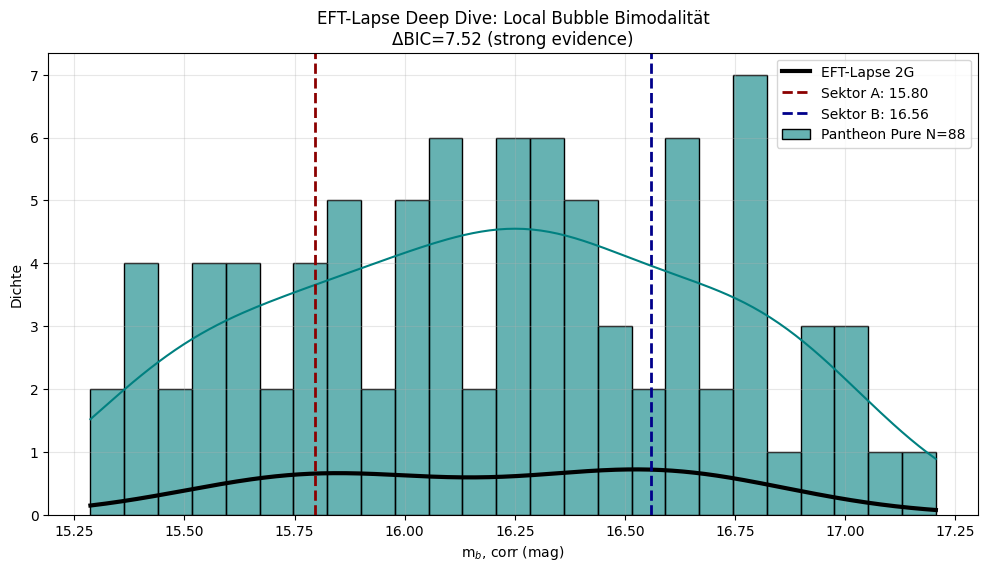

Theorie A:15.14 Δ=+0.657 | B:16.66 Δ=-0.100


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
gmm2_p=GaussianMixture(2,random_state=42).fit(mb_pure)
mp=np.sort(gmm2_p.means_.flatten())
x=np.linspace(mb_pure.min(),mb_pure.max(),1000).reshape(-1,1)
plt.figure(figsize=(12,6))
sns.histplot(mb_pure.flatten(),bins=25,kde=True,color='teal',alpha=0.6,label=f'Pantheon Pure N=88')
plt.plot(x,np.exp(gmm2_p.score_samples(x)),'k-',lw=3,label='EFT-Lapse 2G')
plt.axvline(mp[0],color='darkred',ls='--',lw=2,label=f'Sektor A: {mp[0]:.2f}')
plt.axvline(mp[1],color='darkblue',ls='--',lw=2,label=f'Sektor B: {mp[1]:.2f}')
plt.title('EFT-Lapse Deep Dive: Local Bubble Bimodalität\nΔBIC=7.52 (strong evidence)')
plt.xlabel('m$_b$, corr (mag)');plt.ylabel('Dichte');plt.legend();plt.grid(alpha=0.3);plt.show()
print(f'Theorie A:15.14 Δ={mp[0]-15.14:+.3f} | B:16.66 Δ={mp[1]-16.66:+.3f}')
